```{figure} ../images/alpaca/digital_analog_pins.png
---
width: 250px
name: Connect USB-C to energy hub and Micro USB to Student Pico
class: no-invert
align: right
---
```

# Generating/Acquiring signals
On ALPACA, you can use the digital pins <font color="#bd76e7">**DI (Digital Input)**</font> and <font color="#610a93">**DO (Digital Output)**</font> to receive/create digital signals from the ALPACA.

To <font color="#ea9943">capture analog signals</font> you need to use <font color="#ea9943">**ADC** (Analog-to-Digital Converter)</font> and to <font color="#9e5508">generate</font> them you need to use the <font color="#9e5508">**DAC (Digital-to-Analog Converter)**</font>.

## Background: Digital vs Analog Signals

Signals differ by their nature, **<font color="#9f1ceb">digital</font>** and **<font color="#eb871c">analog</font>**. Both of them are used transmit information but in different formats.

**<font color="#9f1ceb">Digital signals</font>** can be either **ON or OFF** high voltage or low voltage, 1 or 0, TRUE or FALSE, High or Low... They are binary therefore minor electronic noise does not affect the signal's integrity.

**<font color="#eb871c">Analog signals</font>** are continous and smooth, like a sine-wave. Unlike digital, they **can take on any value within a defined range**. Because they are continuous, they are highly sensitive to electronic noise.

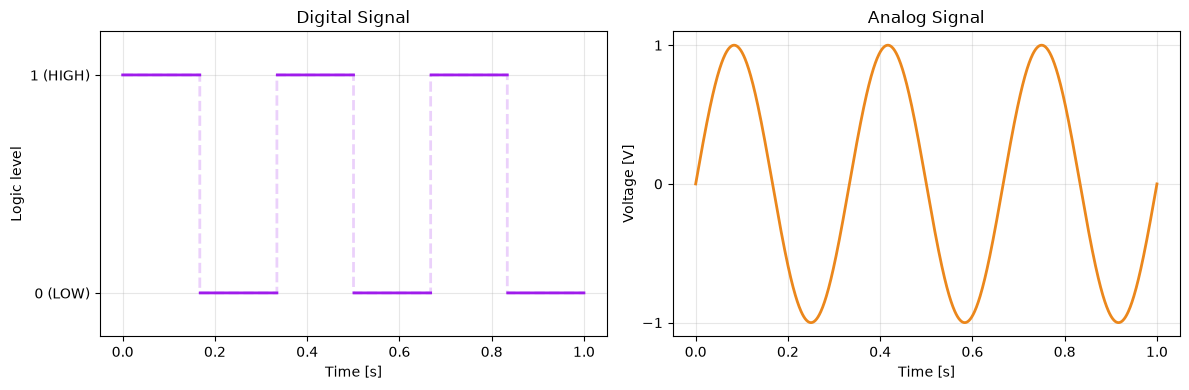

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 1000)
f = 3

analog = np.sin(2 * np.pi * f * t)
digital = (np.sin(2 * np.pi * f * t) >= 0).astype(float)


fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

ax1.plot(t, analog, color="#eb871c", linewidth=2)
ax1.set_title("Analog Signal")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.set_yticks([-1, 0, 1])
ax1.grid(alpha=0.3)

ax2.step(t, digital, color="#9f1ceb", linewidth=2, where="post", linestyle="dashed", alpha=.2)

transitions = np.diff(digital) != 0
digital[1:][transitions] = np.nan

ax2.step(t, digital, color="#9f1ceb", linewidth=2, where="post")

ax2.set_title("Digital Signal")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Logic level")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0 (LOW)", "1 (HIGH)"])
ax2.set_ylim(-0.2, 1.2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Dealing with Digital Signals

Generation and acquisition of <font color="#9f1ceb">digital signals</font> is fairly easy via the **digital pins (DI and DO)**. The digital pins

To access the digital pins on the ALPACA, use the `Pin` object from the module `machine`.

Pins can detect whether there's a HIGH or LOW voltage at their respective pins (essentially the digital signal).

**Pin(`pin_number`, `pin_type`, value=`value`)**

- `pin_number` is the number of the pin, for instance `DO10`'s pin number is `10`

- `pin_type` specifies what type of pin it is:
    - `Pin.OUT`: for outputing signals
    - `Pin.IN`: for receiving signals

- `value` valid only for `Pin.OUT` specifies initial output pin value if given

The following code will <font color="#610a93">**turn on the LED and later turn off**</font>

```python
@pico.task
def turn_on():
    global led
    from machine import Pin

    led = Pin(10, Pin.OUT, value=0) # Digital Output 10
    led.value(1) # Set DO10 to HIGH (3.3V)

@pico.task
def turn_off():
    led.value(0) # Set DO10 to LOW (0V)

turn_on()
input("Press ENTER to turn off the LED") # Waits until an input is given in the console
turn_off()
```


```{figure} ../images/alpaca/led_digital_output.avif
---
max-height: 300px
name: ALPACA Digital Output Example
class: no-invert
---
```

You can also use the same logic <font color="#bd76e7">**to read from a Pin**</font>

```python
@pico.task
def read_pin():
    from machine import Pin

    di14 = Pin(14, Pin.IN) # Digital Input 14
    return di14.value()

print(read_pin())
```


```{figure} ../images/alpaca/led_digital_input.avif
---
max-height: 300px
name: ALPACA Digital Input Example
class: no-invert
---
```

```{tip}
The digital pins have **high impedance (very high resistance)**, so you can treat them as if the wire isn't connected to anything else.
```


## Analog Signals

<font color="#eb871c">Analog signals</font> can take any value and are continous. Since the chip is a digital system operating on 0s and 1s, you need to use need to use either <font color="#ea9943">**ADC** (Analog-to-Digital Converter)</font> for acquisition and  <font color="#9e5508">**DAC** (Digital-to-Analog Converter)</font> for generation.

Compared to digital signals, they are a bit different to use.

### Acquisition: ADC (Analog-to-Digital Converter)

On ALPACA there are 3 ADCs located: <font color="#ea9943">**Pins 26 (ADC0), 27 (ADC1), 28 (ADC2)**</font>.

ADCs allow you to read any voltages in their range programmatically.

```python
from machine import ADC

adc0 = ADC(26) # ADC0 located on Pin 26

value = adc0.read_u16() # Where is voltage?
```

But what is `read_u16()`? <font color="#ea5443">**ADC doesn't directly return a voltage in volts**</font>. Instead, it measures the voltage as a <font color="#435fea">**percentage of the maximum voltage (called the reference voltage or $V_\text{ref}$)**</font> it can read (3V by default). `read_u16` converts that percentage into a 16-bit number ranging from 0 to 65,535 $= 2^{16}$.

- 0 means 0% (0V)
- 65,535 means 100% (3V)
- 32,768 means 50% (1.5V)

So in Python this conversion can be done as:

```python
voltage = adc0.read_u16() * 3 / 2**16
```

```{caution}
If you try to supply a voltage outside of an ADC's range (0-3V), you results **will get clipped between these two values**.
```

<font color="#ea9943">**ADC2**</font> is located next to student pico (check [this image](#generating-acquiring-signals)) and is a simple Analog-to-Digital converter **without any attenuation, gain or coupling (you'll see what these are in a bit)**, it simply can read out voltaged between 0-3V.

###### Differential, Attenuation, Gain and Coupling

```{figure} ../images/alpaca/adcs.png
---
height: 300px
name: ADC ports and switches for Attenuation, Gain and Coupling
class: no-invert
---
```

**Differential**, <font color="#00a20d">**attenuation**</font>, <font color="#7000ba">**gain**</font> and <font color="#ba0000">**coupling**</font> all help you to mitigate your signal so it fits in the 0-3V window of your ADC.

By now, you might have realized both <font color="#ea9943">**ADC0**</font> and <font color="#ea9943">**ADC1**</font> have 2 pins instead of one. This is because ALPACA allows you to measure differential voltage between these two pins:

$$
U_{\text{diff}} = U_{+} - U_{-}
$$

This might seem confusing, however when (-) pin is connected GNDA (analog ground) $U_{-}=0$; therefore, $U_{\text{diff}}=U_{+}$ which makes it a simple ADC pin. So for most measurements you will keep the jumper there.

<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">🚩 TODO: Figure out why differential voltage might be useful at the beginning.</span>

<font color="#7000ba">**Gain**</font> is how much is your signal is <font color="#7000ba">amplified</font> before going into <font color="#ea9943">**ADC**</font>, and <font color="#00a20d">**attenuation**</font> is the <font color="#005f18">exact opposite</font>.

$$
U_{\text{ADC}} = \frac{\textcolor{#7000ba}{\text{Gain}}}{\textcolor{#00a20d}{\text{Attenuation}}} \cdot U_{\text{diff}}
$$

```{figure} ../images/alpaca/analog_signal.avif
---
max-height: 300px
name: Connect USB-C to energy hub and Micro USB to Student Pico
class: no-invert
---
```

```{tip}
When you apply gain to a signal, you also amplify the noise. Because of this, amplifying extremely faint signals is not always practical (SNR is the same even during amplification).

Attenuating to very small signals presents similar challenges: the ADCs may fail to read low voltages accurately. Additionally, signal integrity is compromised, as noise as low as $0.01\text{ mV}$ can disrupt the signal
```


```{admonition} Question
If you set <font color="#7000ba">Gain=1x</font> and <font color="#00a20d">Attenuation=10x</font> (indicated as 0.1x gain on the board),  what is your new range of reading?
```

```{admonition} Answer
:class: answer, dropdown

Plugging in $U_{\text{ADC, max}}=3V$ should give you your range

$$
\begin{align}
U_{\text{ADC, max}} = 3 &= \frac{\textcolor{#7000ba}{1}}{\textcolor{#00a20d}{10}} \cdot U_{\text{diff, max}} \\
U_{\text{diff, max}} &= 30 \text{V}
\end{align}
$$

Therefore you can read between 0-30V.
```

```{admonition} Question
How can you read voltages between **-3V - 0,** without implementing an extra circuit?
```

```{admonition} Answer
:class: answer, dropdown

By moving the jumper from $U_{-}$ ↔ *GNDA* to $U_{+}$ ↔ *GNDA* and hooking up the signal into $U_{-}$!

Connecting $U_{+}$ to ground results in $U_{+}=0$, so $U_{\text{diff}}=-U_{-}$.

With 1x Gain and Attenuation the voltage at ADC is:

$$
U_{\text{ADC}} = -U_{-}
$$

So your range becomes from -3V to 0V:

```python
voltage = adc0.read_u16() * -3.3 / 2**16
```


<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">🚩 TODO: Do we spoil what AC/DC coupling is here?</span>

### Generation: DAC (Digital-to-Analog Converter)

````{admonition} Background: lambda functions
:class: note, dropdown

In Python writing a simple functions with multiple lines can be eye-tiring and spacing occupying

```python
def increment(i):
    return i + 1

some_other_function(increment)
```

There exists a special syntax called <font color="#6730C5">**lambda functions**</font> that allows you to write simple functions in smaller spaces.

```python
some_other_function(lambda i: i + 1)
```

where `i` is the argument and `i + 1` is the return value. You can even store this function in a variable to use it.


```python
increment = lambda i: i + 1

print(increment(1)) # 2
```

This is just a writing style and doesn't change the behaviour of your code.
````


On ALPACA there are 2 DACs located: <font color="#9e5508">**DAC A**</font> and <font color="#9e5508">**DAC B**</font>. Both of these outputs allow you to output analog signals independently.

Just like ADC ports they <font color="#FF9306">**work on a $V_\text{ref}$**</font>, therefore, DAC can output from 0 to $V_\text{ref}$ and they also have a 1x and 2x Gain that you can set programatically.

```{figure} ../images/alpaca/dac_reference.png
---
max-height: 300px
name: DAC Reference Pins
class: no-invert
---
```

The conversion is done internally so you don't have to convert $2^{16}$ to whatever Volts.

#### Signal clarity

DAC operates on a 12-bit basis (so $2^{12}$), therefore it can only express the values as steps of $2^{12}$, just like [ADC](#acquisition-adc-analog-to-digital-converter)! Therefore the smallest voltage change the DAC can output is

$$
\text{Smallest Step} = \frac{V_\text{ref}}{2^{12} (=4096)}
$$

Therefore choosing $2048\text{mV}$ instead of $3\text{V}$ as reference can give you a finer signal resolution.


````{admonition} So for example if you try to output $1 \text{V}$:
:class: tip

**With $V_\text{ref}=3\text{V}$:**

$$
\text{Smallest Step} = \frac{3000}{2^{12} (=4096)} \approx 0.7324 \text{mV}

V_\text{out} = ~0.73 x \underset{\text{Step count (int)}}{1365} = \color{red}{999.75 \text{mV}}
$$

**With $V_\text{ref}=2048\text{mV}$:**

$$
\text{Smallest Step} = \frac{2048}{2^{12} (=4096)} = 0.5 \text{mV} \\ \space \\

V_\text{out} = 0.5 x \underset{\text{Step count (int)}}{2000} = \color{blue}{1 \text{V}}
$$

````



#### DC Output

Setting a DC Output is extremely easy! By using the `DAC` object you can write an output in both DACs.

```python
@pico.task
def set_voltage():
    from dac import DAC

    # Channel "A" or "B
    # v_ref = 3000 or 2048 (defaults to 3000 if not provided)
    dac_a = DAC("A", v_ref=3000, gain=1)

    dac_a.write(1.5)
```

#### AC Output

AC output varies overtime and requires you to provide a *function* with a <font color="#0057c0">frequency</font> and <font color="#00c086">sample count</font> to synthesize an AC waveform.

<font color="#0057c0">**Frequency (in ms)**</font> determines how fast your signal is going to be.

<font color="#00c086">**Sample count (N)**</font> is how many times should the DAC update your signal in one period. So a higher sample count results in smoother waves.

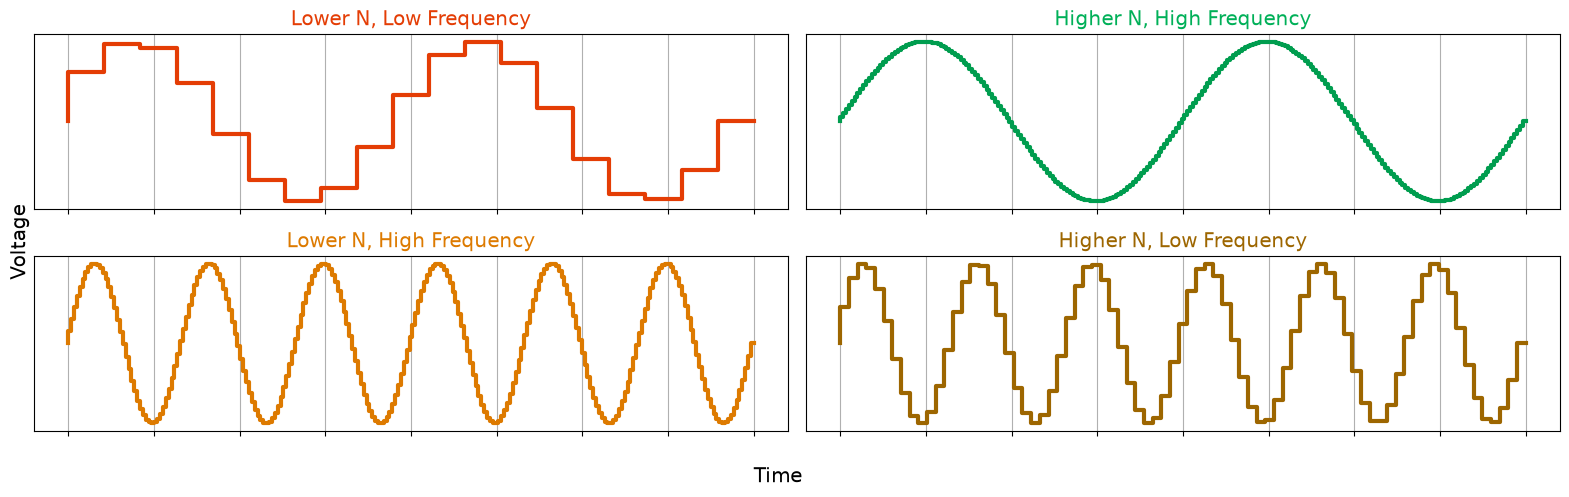

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 12})

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 5), sharex=True, sharey=True)

axs: list[plt.Axes] = [ax1, ax2, ax3, ax4] # type: ignore

for ax in axs:
    ax.xaxis.set_major_formatter(plt.NullFormatter())
    ax.set_yticks([])

    ax.grid()

high_freq = np.pi * 6
low_freq = np.pi * 2

lower_n = np.linspace(0, 2, 20)
higher_n = np.linspace(0, 2, 80)
higher_n3 = np.linspace(0, 2, 80 * 3)

ax1.step(lower_n, np.sin(low_freq * lower_n), linewidth=3, color="#e43d05")
ax1.set_title("Lower N, Low Frequency", color="#e43d05")

ax2.step(higher_n3, np.sin(low_freq * higher_n3), linewidth=3, color="#009d4f")
ax2.set_title("Higher N, High Frequency", color="#00b058")

ax3.step(higher_n3, np.sin(high_freq * higher_n3), linewidth=3, color="#dd7a00")
ax3.set_title("Lower N, High Frequency", color="#dd7a00")

ax4.step(higher_n, np.sin(high_freq * higher_n), linewidth=3, color="#9d6600")
ax4.set_title("Higher N, Low Frequency", color="#9d6600")

fig.supxlabel("Time")
fig.supylabel("Voltage")

fig.tight_layout();

Using the DAC object, you can generate custom signals.

```python
@pico.task
def setup():
    from dac import DAC

    global dac_a

    dac_a = DAC("A")

@pico.task
def sine_wave():
    import math
    import utime

    with dac_a.generate(
       lambda t: 2.048 / 2 * (math.sin(t * 2 * math.pi) + 1),
       frequency_hz=100,
       N=200):
      utime.sleep(10) # The output lasts second
```

The first parameter passed to `generate()` is <font color="#c01d00">**the waveform**, the function that defines the shape of your signal</font>. This function:

- takes a single input `t`, which will range between 0 and 1
- should return the signal's value at that point in time
- must describe exactly **one period** of the signal

So for a sine wave, as t goes from `0` to `1`, `t * 2 * math.pi` goes from `0` to `2π`, tracing out one full cycle of the sine function.

```{figure} ../images/alpaca/DAC_visualizer.avif
---
max-height: 300px
name: Connect USB-C to energy hub and Micro USB to Student Pico
class: no-invert
---
```